# Laboratorio 3 - Regresión Lineal Multivariable, Regresión Polinómica y Ecuación de la Normal

## Dataset: Evaluación de Riesgo Financiero y Solicitud de Préstamos (`Loan.csv`)

### ¿Qué vamos a predecir?
En este laboratorio predeciremos la variable continua **`RiskScore`** (Puntuación de evaluación de riesgo crediticio/financiero del solicitante).

- **Variable Objetivo ($y$):** `RiskScore` (puntuación entre 0 y 100 que indica el riesgo de impago o inestabilidad financiera).
- **¿Por qué `RiskScore` y no `LoanApproved`?**: Porque el presente laboratorio está dedicado a modelos de **regresión** (Regresión Lineal Multivariable, Regresión Polinómica y Ecuación de la Normal), los cuales requieren una variable de salida numérica continua. La variable `LoanApproved` es binaria (0/1) y está destinada a modelos de clasificación (como la Regresión Logística).

Para cada modelo se incluye su gráfico de costo, entrenamiento y validación con **4,000 predicciones** (superando la cuota mínima de 100).

## 1. Importación de librerías

Se importan las librerías científicas fundamentales de Python (`numpy`, `pandas`, `matplotlib`) y los módulos de `scikit-learn` del cuadernillo 06 (`PolynomialFeatures`, `LinearRegression`, `mean_squared_error`, `r2_score`).

In [42]:
# Librerías para álgebra lineal, manejo de datos y visualizaciones
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
%matplotlib inline

# Importaciones del cuadernillo 06 (scikit-learn)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

## 2. Carga y limpieza de datos

Siguiendo el estilo de limpieza del Laboratorio 2:
- Se identifican y convierten las columnas categóricas de texto a valores numéricos usando `pd.factorize()`.
- Se remueve la columna `ApplicationDate` (cadena de texto no directa para regresión).
- Se remueve la columna `LoanApproved` (etiqueta binaria de clasificación).
- Se extrae `RiskScore` como la variable objetivo continua ($y$).
- Se verifica la integridad de los datos (sin valores nulos NaN y en tipo numérico `float64`).

In [43]:
# Definir ruta del dataset
dataset = 'Loan.csv'
print(f'Archivo a usar: {os.path.abspath(dataset)}')

Archivo a usar: e:\USFX\7mo Semestre\Inteligencia Artificial\Laboratorios\Laboratorio3\Loan.csv


In [44]:
# Carga del conjunto de datos con pandas
df = pd.read_csv(dataset)

# Limpieza y conversión de columnas de texto categóricas a valores numéricos
cols_texto = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']
for col in cols_texto:
    df[col] = df[col].astype(str).str.strip()
    df[col], categorias = pd.factorize(df[col])
    print(f"Columna '{col}' codificada: {list(categorias)}")

# Extracción de la variable objetivo (y): RiskScore
y = df['RiskScore'].values.astype(float)

# Eliminación de columnas no aplicables para regresión continua (Date, Classification Label, Target)
columnas_excluidas = ['ApplicationDate', 'LoanApproved', 'RiskScore']
df_X = df.drop(columns=columnas_excluidas)
X_original = df_X.values.astype(float)

m = y.size
n = X_original.shape[1]

print(f"\nDimensiones del dataset: {m} ejemplos (m >= 2000), {n} propiedades (n >= 20)")
print(f"Tipo de datos de X: {X_original.dtype}")
print(f"Total de datos nulos (NaN): {np.isnan(X_original).sum()}")

Columna 'EmploymentStatus' codificada: ['Employed', 'Self-Employed', 'Unemployed']
Columna 'EducationLevel' codificada: ['Master', 'Associate', 'Bachelor', 'High School', 'Doctorate']
Columna 'MaritalStatus' codificada: ['Married', 'Single', 'Divorced', 'Widowed']
Columna 'HomeOwnershipStatus' codificada: ['Own', 'Mortgage', 'Rent', 'Other']
Columna 'LoanPurpose' codificada: ['Home', 'Debt Consolidation', 'Education', 'Other', 'Auto']

Dimensiones del dataset: 20000 ejemplos (m >= 2000), 33 propiedades (n >= 20)
Tipo de datos de X: float64
Total de datos nulos (NaN): 0


## 3. Funciones auxiliares vectorizadas

Se implementan las funciones para normalización de características, cálculo del costo $J(\theta)$, descenso por el gradiente y ecuación de la normal.

In [45]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1.0
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

def computeCostMulti(X, y, theta):

    m = y.shape[0]
    J = (1.0 / (2.0 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):

    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))
    return theta, J_history

def normalEqn(X, y):

    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

## 4. División del dataset (80% Entrenamiento, 20% Prueba)

Se realiza una división aleatoria con semilla fija (`seed=42`) para garantizar la reproducibilidad de las pruebas entre los tres modelos.

In [46]:
# División 80% entrenamiento (16,000) y 20% prueba (4,000)
np.random.seed(42)
m_total = X_original.shape[0]
indices = np.random.permutation(m_total)

corte = int(0.8 * m_total)
idx_train, idx_test = indices[:corte], indices[corte:]

y_train, y_test = y[idx_train], y[idx_test]

print(f"Muestras de Entrenamiento: {len(idx_train)} filas")
print(f"Muestras de Prueba (Validación): {len(idx_test)} filas (cumple con la condición de >= 100 predicciones)")

Muestras de Entrenamiento: 16000 filas
Muestras de Prueba (Validación): 4000 filas (cumple con la condición de >= 100 predicciones)


---
## 5. MODELO 1: Regresión Lineal Multivariable

Se entrena el modelo de regresión lineal utilizando las 33 propiedades del dataset normalizadas mediante el descenso por el gradiente.

**Hipótesis:** $h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + ... + \theta_{33} x_{33}$

**Función de costo:** $J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)})^2$

In [47]:
# Preparación y normalización de datos para la regresión lineal
X_train_lin = X_original[idx_train]
X_test_lin = X_original[idx_test]

X_train_norm, mu_lin, sigma_lin = featureNormalize(X_train_lin)
X_test_norm = (X_test_lin - mu_lin) / sigma_lin

# Adición de columna de unos (sesgo theta_0)
m_train = X_train_norm.shape[0]
m_test = X_test_norm.shape[0]
X_train_lin_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_lin_b = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print(f'Dimensiones X_train (con sesgo): {X_train_lin_b.shape}')
print(f'Dimensiones X_test (con sesgo): {X_test_lin_b.shape}')

Dimensiones X_train (con sesgo): (16000, 34)
Dimensiones X_test (con sesgo): (4000, 34)


In [48]:
# Entrenamiento mediante Descenso por el Gradiente Multivariable
alpha_lin = 0.001
num_iters_lin = 10000

theta_lin = np.zeros(X_train_lin_b.shape[1])
theta_lin, J_history_lin = gradientDescentMulti(X_train_lin_b, y_train, theta_lin, alpha_lin, num_iters_lin)

print(f'Theta calculado (primeros 5 parámetros): {theta_lin[:5]}')
print(f'Costo final alcanzado: {J_history_lin[-1]:.4f}')

Theta calculado (primeros 5 parámetros): [50.74248269 -0.11642427 -1.66426019 -0.422173    1.10612351]
Costo final alcanzado: 6.7448


C:\Users\luisg\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


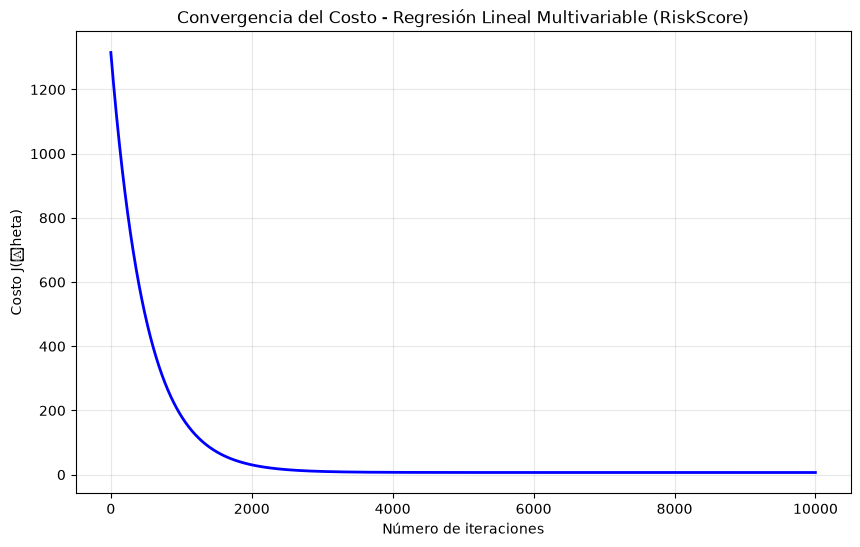

In [49]:
# Gráfica de convergencia del costo - Regresión Lineal Multivariable
pyplot.figure(figsize=(10, 6))
pyplot.plot(np.arange(len(J_history_lin)), J_history_lin, lw=2, color='blue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J(\theta)')
pyplot.title('Convergencia del Costo - Regresión Lineal Multivariable (RiskScore)')
pyplot.grid(True, alpha=0.3)
pyplot.show()

In [50]:
# Evaluación y validación sobre el conjunto de prueba (4,000 predicciones de RiskScore)
y_pred_lin = np.dot(X_test_lin_b, theta_lin)

# Cálculo de métricas de error y precisión
error_lin = y_test - y_pred_lin
mae_lin = np.mean(np.abs(error_lin))
mse_lin = np.mean(error_lin**2)
rmse_lin = np.sqrt(mse_lin)

ss_res_lin = np.sum(error_lin**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_lin = 1.0 - (ss_res_lin / ss_tot)

print(f'=== Regresión Lineal Multivariable ===')
print(f'Total de predicciones realizadas: {len(y_pred_lin)}')
print(f'MAE (Error Absoluto Medio): {mae_lin:.4f}')
print(f'MSE (Error Cuadrático Medio): {mse_lin:.4f}')
print(f'RMSE (Raíz del Error Cuadrático Medio): {rmse_lin:.4f}')
print(f'R² (Coeficiente de Determinación): {r2_lin:.4f}')

# Muestra de las primeras 20 predicciones vs valores reales de RiskScore
print(f'\nPrimeras 20 predicciones de RiskScore vs Valores Reales:')
print(f'{"Predicción":>22} {"Real":>8} {"Diferencia":>12}')
print('-' * 44)
for i in range(20):
    print(f'{y_pred_lin[i]:22.2f} {y_test[i]:8.2f} {error_lin[i]:12.2f}')

=== Regresión Lineal Multivariable ===
Total de predicciones realizadas: 4000
MAE (Error Absoluto Medio): 2.8362
MSE (Error Cuadrático Medio): 12.8705
RMSE (Raíz del Error Cuadrático Medio): 3.5875
R² (Coeficiente de Determinación): 0.7835

Primeras 20 predicciones de RiskScore vs Valores Reales:
            Predicción     Real   Diferencia
--------------------------------------------
                 40.91    48.00         7.09
                 42.34    38.40        -3.94
                 71.08    68.00        -3.08
                 54.43    56.00         1.57
                 49.04    55.00         5.96
                 55.16    61.00         5.84
                 54.08    56.00         1.92
                 44.95    44.80        -0.15
                 56.82    57.00         0.18
                 55.88    57.00         1.12
                 51.81    55.00         3.19
                 54.78    56.00         1.22
                 44.59    49.00         4.41
                 49.10    5

---
## 6. MODELO 2: Regresión Polinómica 

1. Se genera la matriz polinómica usando `PolynomialFeatures(degree=2, include_bias=False)` de `scikit-learn`.
2. Se normalizan las características polinómicas para garantizar estabilidad numérica.
3. Se entrena el modelo polinómico usando `LinearRegression()` de `scikit-learn` y se extraen los parámetros con la sintaxis exacta del cuadernillo 06: `regresion_lineal.coef_` (vector de coeficientes $\theta$) y `regresion_lineal.intercept_` (intercepto $b$ o $\theta_0$).
4. Se calculan las métricas usando `mean_squared_error` ($MSE$), $RMSE = \sqrt{MSE}$ y `r2_score` ($R^2$) de `sklearn.metrics` exactamente como en el cuadernillo 06.
5. Adicionalmente, se ejecuta el Descenso por el Gradiente para obtener el historial y la curva de costo $J(\theta)$ requeridos en la guía del laboratorio.

In [51]:
# 1. Generar características polinómicas usando PolynomialFeatures
pf = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_raw = pf.fit_transform(X_original[idx_train])
X_test_poly_raw = pf.transform(X_original[idx_test])

print(f'Dimensiones de X transformado polinómicamente con PolynomialFeatures: {X_train_poly_raw.shape}')

# 2. Normalización de características polinómicas
X_train_pol_norm, mu_pol, sigma_pol = featureNormalize(X_train_poly_raw)
X_test_pol_norm = (X_test_poly_raw - mu_pol) / sigma_pol

# 3. Entrenamiento con LinearRegression
regresion_lineal = LinearRegression()
regresion_lineal.fit(X_train_pol_norm, y_train)

# Extracción de parámetros estimados 
print('\nParámetros estimados (Sintaxis Cuadernillo 06):')
print('theta (primeros 5 coeficientes) = ' + str(regresion_lineal.coef_[:5]))
print('b (intercepto) = ' + str(regresion_lineal.intercept_))

# Adición de columna de unos para el Descenso por el Gradiente
m_train_pol = X_train_pol_norm.shape[0]
m_test_pol = X_test_pol_norm.shape[0]
X_train_pol_b = np.concatenate([np.ones((m_train_pol, 1)), X_train_pol_norm], axis=1)
X_test_pol_b = np.concatenate([np.ones((m_test_pol, 1)), X_test_pol_norm], axis=1)

print(f'\nDimensiones X_train Polinómica con sesgo (train): {X_train_pol_b.shape}')
print(f'Dimensiones X_test Polinómica con sesgo (test): {X_test_pol_b.shape}')

Dimensiones de X transformado polinómicamente con PolynomialFeatures: (16000, 594)

Parámetros estimados (Sintaxis Cuadernillo 06):
theta (primeros 5 coeficientes) = [-1.33595182 -2.31872021  2.99650385  1.0976304   0.64109236]
b (intercepto) = 50.74477499999941

Dimensiones X_train Polinómica con sesgo (train): (16000, 595)
Dimensiones X_test Polinómica con sesgo (test): (4000, 595)


In [62]:
# Entrenamiento de la Regresión Polinómica mediante Descenso por el Gradiente (para curva de costo)
alpha_pol = 0.001
num_iters_pol = 10000

theta_pol = np.zeros(X_train_pol_b.shape[1])
theta_pol, J_history_pol = gradientDescentMulti(X_train_pol_b, y_train, theta_pol, alpha_pol, num_iters_pol)

print(f'Theta polinómico optimizado (primeros 5 parámetros): {theta_pol[:5]}')
print(f'Costo final alcanzado J(\theta): {J_history_pol[-1]:.4f}')

Theta polinómico optimizado (primeros 5 parámetros): [50.74248269 -0.14168135 -0.63024305 -0.17997683  0.20922843]
Costo final alcanzado J(	heta): 4.8113


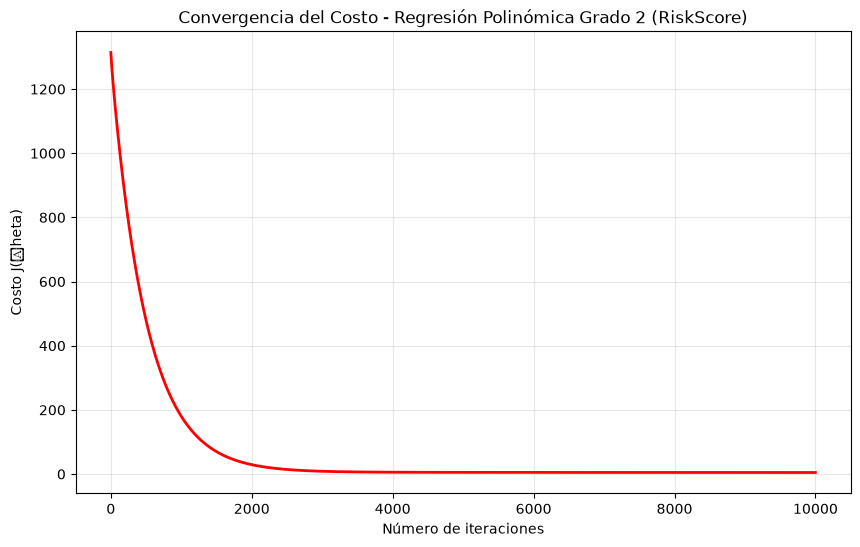

In [63]:
# Gráfica de convergencia del costo - Regresión Polinómica
pyplot.figure(figsize=(10, 6))
pyplot.plot(np.arange(len(J_history_pol)), J_history_pol, lw=2, color='red')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J(\theta)')
pyplot.title('Convergencia del Costo - Regresión Polinómica Grado 2 (RiskScore)')
pyplot.grid(True, alpha=0.3)
pyplot.show()

In [64]:
# Evaluación y predicción en el conjunto de prueba (Sintaxis y métricas del Cuadernillo 06)
prediccion_test = regresion_lineal.predict(X_test_pol_norm)
y_pred_pol = prediccion_test.copy()

# Métricas exactas del Cuadernillo 06 usando sklearn.metrics
error_pol = y_test - prediccion_test
mae_pol = np.mean(np.abs(error_pol))
mse_pol = mean_squared_error(y_true=y_test, y_pred=prediccion_test)
rmse_pol = np.sqrt(mse_pol)
r2_pol = r2_score(y_true=y_test, y_pred=prediccion_test)

print(f'=== Regresión Polinómica Grado 2 (RiskScore - Métricas Cuadernillo 06) ===')
print(f'Total de predicciones realizadas: {len(prediccion_test)}')
print('Error Cuadrático Medio (MSE) = ' + str(mse_pol))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse_pol))
print('Coeficiente de Determinación R2 = ' + str(r2_pol))
print('Error Absoluto Medio (MAE) = ' + str(mae_pol))

# Muestra de las primeras 20 predicciones vs valores reales
print(f'\nPrimeras 20 predicciones de RiskScore vs Valores Reales:')
print(f'{"Predicción RiskScore":>22} {"Real":>8} {"Diferencia":>12}')
print('-' * 44)
for i in range(20):
    print(f'{y_pred_pol[i]:22.2f} {y_test[i]:8.2f} {error_pol[i]:12.2f}')

=== Regresión Polinómica Grado 2 (RiskScore - Métricas Cuadernillo 06) ===
Total de predicciones realizadas: 4000
Error Cuadrático Medio (MSE) = 8.62491607347461
Raíz del Error Cuadrático Medio (RMSE) = 2.9368207424823547
Coeficiente de Determinación R2 = 0.8548963653149383
Error Absoluto Medio (MAE) = 2.274980760220899

Primeras 20 predicciones de RiskScore vs Valores Reales:
  Predicción RiskScore     Real   Diferencia
--------------------------------------------
                 43.44    48.00         4.56
                 43.17    38.40        -4.77
                 70.47    68.00        -2.47
                 56.68    56.00        -0.68
                 50.54    55.00         4.46
                 53.42    61.00         7.58
                 55.59    56.00         0.41
                 45.32    44.80        -0.52
                 57.50    57.00        -0.50
                 56.25    57.00         0.75
                 52.65    55.00         2.35
                 56.05    56.00    

---
## 7. MODELO 3: Ecuación de la Normal

Se calcula los parámetros $\theta$ directamente sin iteraciones ni necesidad de escalar/normalizar las características:

$$\theta = (X^T X)^{-1} X^T \vec{y}$$

Solo se añade la columna de unos a la matriz de datos original $X$ sin escalar.

In [65]:
# Preparación de datos para la Ecuación de la Normal (datos sin normalizar)
X_train_normal = X_original[idx_train]
X_test_normal = X_original[idx_test]

m_train_n = X_train_normal.shape[0]
m_test_n = X_test_normal.shape[0]
X_train_normal_b = np.concatenate([np.ones((m_train_n, 1)), X_train_normal], axis=1)
X_test_normal_b = np.concatenate([np.ones((m_test_n, 1)), X_test_normal], axis=1)

print(f'Dimensiones X_train (Ecuación de la Normal): {X_train_normal_b.shape}')

Dimensiones X_train (Ecuación de la Normal): (16000, 34)


In [66]:
# Cálculo analítico de theta
theta_normal = normalEqn(X_train_normal_b, y_train)

print(f'Theta calculado por la Ecuación de la Normal (primeros 5 parámetros): {theta_normal[:5]}')

Theta calculado por la Ecuación de la Normal (primeros 5 parámetros): [ 4.18400844e+01  7.57776106e-04 -1.36021260e-05 -1.45309114e-03
  1.98071548e+00]


C:\Users\luisg\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


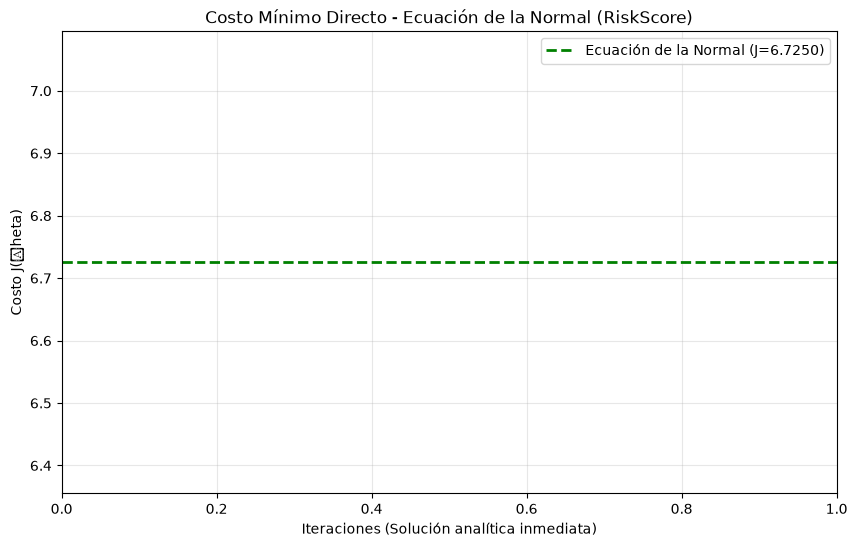

Costo final analítico J(theta): 6.7250


In [67]:
# Cálculo del costo directo (solución analítica)
costo_normal = computeCostMulti(X_train_normal_b, y_train, theta_normal)

pyplot.figure(figsize=(10, 6))
pyplot.axhline(y=costo_normal, color='green', linestyle='--', linewidth=2, label=f'Ecuación de la Normal (J={costo_normal:.4f})')
pyplot.xlabel('Iteraciones (Solución analítica inmediata)')
pyplot.ylabel('Costo J(\theta)')
pyplot.title('Costo Mínimo Directo - Ecuación de la Normal (RiskScore)')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.show()

print(f'Costo final analítico J(theta): {costo_normal:.4f}')

In [68]:
# Validación de la Ecuación de la Normal sobre el conjunto de prueba
y_pred_normal = np.dot(X_test_normal_b, theta_normal)

# Métricas de evaluación
error_normal = y_test - y_pred_normal
mae_normal = np.mean(np.abs(error_normal))
mse_normal = mean_squared_error(y_true=y_test, y_pred=y_pred_normal)
rmse_normal = np.sqrt(mse_normal)
r2_normal = r2_score(y_true=y_test, y_pred=y_pred_normal)

print(f'=== Ecuación de la Normal ===')
print(f'Total de predicciones realizadas: {len(y_pred_normal)}')
print('Error Absoluto Medio (MAE) = ' + str(mae_normal))
print('Error Cuadrático Medio (MSE) = ' + str(mse_normal))
print('Raíz del Error Cuadrático Medio (RMSE) = ' + str(rmse_normal))
print('Coeficiente de Determinación R2 = ' + str(r2_normal))

# Muestra de las primeras 20 predicciones vs valores reales
print(f'\nPrimeras 20 predicciones de RiskScore vs Valores Reales:')
print(f'{"Predicción ":>22} {"Real":>8} {"Diferencia":>12}')
print('-' * 44)
for i in range(20):
    print(f'{y_pred_normal[i]:22.2f} {y_test[i]:8.2f} {error_normal[i]:12.2f}')

=== Ecuación de la Normal ===
Total de predicciones realizadas: 4000
Error Absoluto Medio (MAE) = 2.826576856479252
Error Cuadrático Medio (MSE) = 12.820983763443362
Raíz del Error Cuadrático Medio (RMSE) = 3.580640133194533
Coeficiente de Determinación R2 = 0.7843026728068405

Primeras 20 predicciones de RiskScore vs Valores Reales:
           Predicción      Real   Diferencia
--------------------------------------------
                 41.07    48.00         6.93
                 42.37    38.40        -3.97
                 71.13    68.00        -3.13
                 54.40    56.00         1.60
                 49.14    55.00         5.86
                 55.25    61.00         5.75
                 54.37    56.00         1.63
                 44.79    44.80         0.01
                 56.76    57.00         0.24
                 56.09    57.00         0.91
                 51.77    55.00         3.23
                 54.78    56.00         1.22
                 44.52    49.00   

---
## 8. Comparación y Evaluación de los Tres Modelos

Se presentan las gráficas y la tabla resumen con las métricas de desempeño de los tres enfoques de regresión aplicados a la predicción del `RiskScore`.

C:\Users\luisg\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


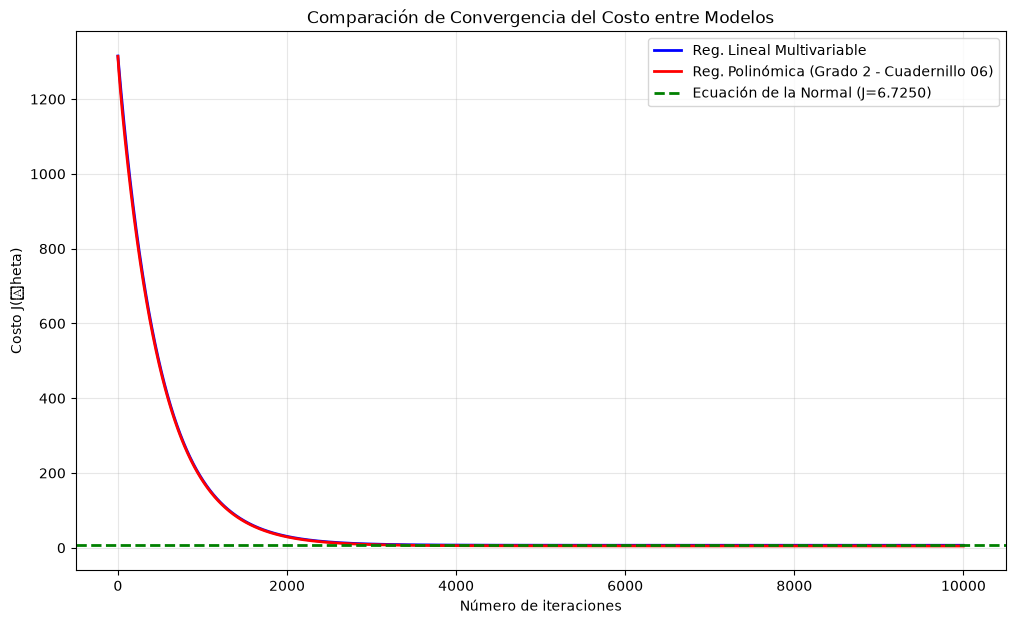

In [69]:
# Gráfico comparativo de costo de los 3 modelos
pyplot.figure(figsize=(12, 7))
pyplot.plot(np.arange(len(J_history_lin)), J_history_lin, lw=2, color='blue', label='Reg. Lineal Multivariable')
pyplot.plot(np.arange(len(J_history_pol)), J_history_pol, lw=2, color='red', label='Reg. Polinómica (Grado 2 - Cuadernillo 06)')
pyplot.axhline(y=costo_normal, color='green', linestyle='--', linewidth=2, label=f'Ecuación de la Normal (J={costo_normal:.4f})')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J(\theta)')
pyplot.title('Comparación de Convergencia del Costo entre Modelos')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.show()

In [70]:
# Tabla resumen comparativa de métricas
print('=' * 80)
print(f'{"Métrica de Evaluación":>32} {"Lineal Multi":>15} {"Polinómica":>15} {"Ec. Normal":>15}')
print('=' * 80)
print(f'{"MAE (Error Absoluto Medio)":>32} {mae_lin:15.4f} {mae_pol:15.4f} {mae_normal:15.4f}')
print(f'{"MSE (Error Cuadrático Medio)":>32} {mse_lin:15.4f} {mse_pol:15.4f} {mse_normal:15.4f}')
print(f'{"RMSE (Raíz MSE)":>32} {rmse_lin:15.4f} {rmse_pol:15.4f} {rmse_normal:15.4f}')
print(f'{"R² (Coef. Determinación)":>32} {r2_lin:15.4f} {r2_pol:15.4f} {r2_normal:15.4f}')
print(f'{"Total de Predicciones":>32} {len(y_pred_lin):15d} {len(y_pred_pol):15d} {len(y_pred_normal):15d}')
print('=' * 80)

           Métrica de Evaluación    Lineal Multi      Polinómica      Ec. Normal
      MAE (Error Absoluto Medio)          2.8362          2.2750          2.8266
    MSE (Error Cuadrático Medio)         12.8705          8.6249         12.8210
                 RMSE (Raíz MSE)          3.5875          2.9368          3.5806
        R² (Coef. Determinación)          0.7835          0.8549          0.7843
           Total de Predicciones            4000            4000            4000


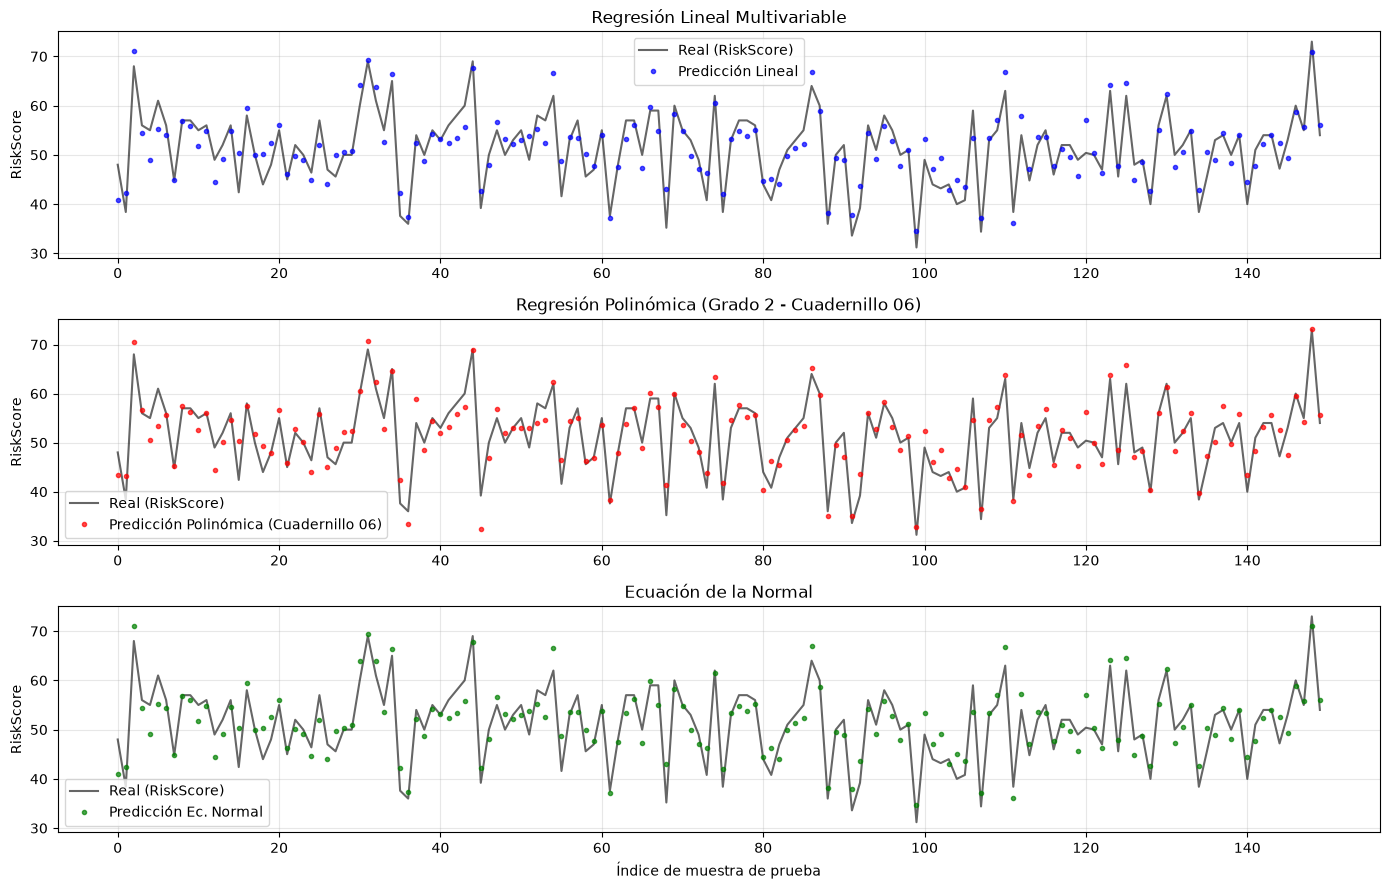

In [71]:
# Gráfico comparativo de Predicciones vs Valores Reales (Muestra de 150 elementos)
n_muestras = 150
x_axis = np.arange(n_muestras)

pyplot.figure(figsize=(14, 9))

pyplot.subplot(3, 1, 1)
pyplot.plot(x_axis, y_test[:n_muestras], 'k-', alpha=0.6, label='Real (RiskScore)')
pyplot.plot(x_axis, y_pred_lin[:n_muestras], 'b.', alpha=0.7, label='Predicción Lineal')
pyplot.title('Regresión Lineal Multivariable')
pyplot.ylabel('RiskScore')
pyplot.legend()
pyplot.grid(True, alpha=0.3)

pyplot.subplot(3, 1, 2)
pyplot.plot(x_axis, y_test[:n_muestras], 'k-', alpha=0.6, label='Real (RiskScore)')
pyplot.plot(x_axis, y_pred_pol[:n_muestras], 'r.', alpha=0.7, label='Predicción Polinómica (Cuadernillo 06)')
pyplot.title('Regresión Polinómica (Grado 2 - Cuadernillo 06)')
pyplot.ylabel('RiskScore')
pyplot.legend()
pyplot.grid(True, alpha=0.3)

pyplot.subplot(3, 1, 3)
pyplot.plot(x_axis, y_test[:n_muestras], 'k-', alpha=0.6, label='Real (RiskScore)')
pyplot.plot(x_axis, y_pred_normal[:n_muestras], 'g.', alpha=0.7, label='Predicción Ec. Normal')
pyplot.title('Ecuación de la Normal')
pyplot.ylabel('RiskScore')
pyplot.xlabel('Índice de muestra de prueba')
pyplot.legend()
pyplot.grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()